In [138]:
import pandas as pd
import numpy as np


In [139]:
df = pd.read_csv("../data/cleaned_forecasting_data.csv",
    index_col=0,
    parse_dates=True
)

In [140]:
df

,no_show,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,...,appointment_shift_morning,disability_motor,disability_none,rain_intensity_moderate,rain_intensity_no_rain,rain_intensity_weak,heat_intensity_heavy_cold,heat_intensity_heavy_warm,heat_intensity_mild,heat_intensity_warm
appointment_date_continuous,,,,,,,,,,,,,,,,,,,,,
2020-01-01,1,9.0,1,0,1,23.18,0.000000,27.5,0.000000,1,...,0,0,0,0,1,0,0,0,0,1
2020-01-01,0,11.0,1,0,1,14.31,0.019803,16.5,0.470004,1,...,1,0,0,0,1,0,0,0,0,0
2020-01-01,0,8.0,1,0,1,21.61,0.009950,29.9,0.182322,1,...,0,0,0,0,1,0,0,0,0,1
2020-01-01,1,9.0,1,0,1,21.39,0.104360,24.1,0.875469,1,...,0,0,0,1,0,0,0,0,1,0
2020-01-01,0,12.0,0,0,0,20.15,0.019803,23.1,0.182322,1,...,1,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-11,1,18.0,0,0,0,18.97,0.000000,25.6,0.182322,1,...,0,0,0,0,1,0,0,0,1,0
2021-05-11,1,18.0,0,0,0,24.46,0.207014,31.4,2.272126,1,...,1,1,0,1,0,0,0,0,0,1
2021-05-11,0,8.0,1,0,1,20.88,0.000000,23.8,1.808289,1,...,0,0,0,1,0,0,0,0,1,0


In [141]:
df.columns

Index(['no_show', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received', 'place_encoded', 'specialty_enf',
       'specialty_occupational therapy', 'specialty_pedagogo',
       'specialty_physiotherapy', 'specialty_psychotherapy',
       'specialty_sem especialidade', 'specialty_speech therapy', 'gender_M',
       'appointment_shift_morning', 'disability_motor', 'disability_none',
       'rain_intensity_moderate', 'rain_intensity_no_rain',
       'rain_intensity_weak', 'heat_intensity_heavy_cold',
       'heat_intensity_heavy_warm', 'heat_intensity_mild',
       'heat_intensity_warm'],
      dtype='object')

Raw data
   ↓
Group by date (DONE ✔)
   ↓
Make y series
   ↓
Train-Test split
   ↓
SARIMA model(Arima)
   ↓
Prediction
   ↓
Evaluation

In [143]:
ts = df.groupby(df.index).size()

In [144]:
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('D')

ARIMA/SARIMA need y series ,Each day how many entries=daily demand

In [145]:
#Sort time
ts = ts.sort_index()

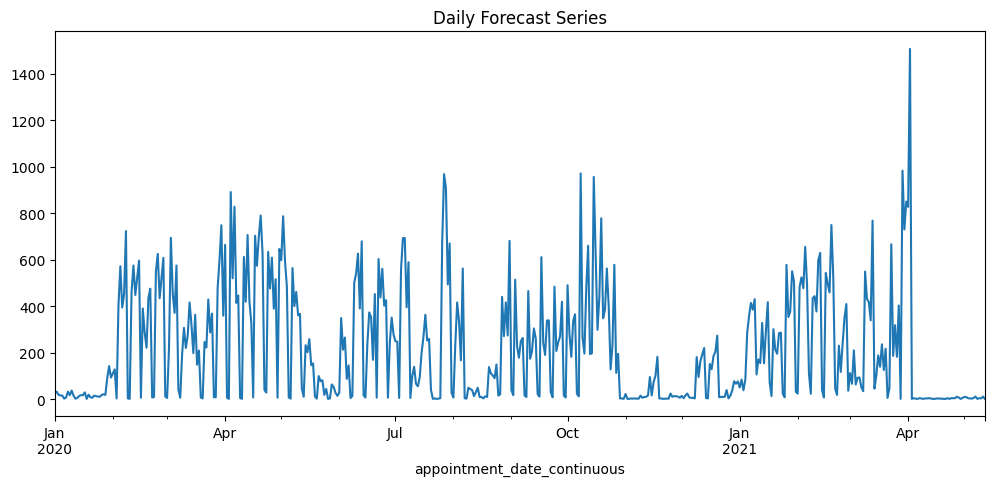

In [146]:
import matplotlib.pyplot as plt

ts.plot(figsize=(12,5))
plt.title("Daily Forecast Series")
plt.show()

Observations:
1. Highly volatile data
More UP and Down Data
No Smooth Treand

2. Seasonal pattern
In some months spikes(high Demand)
In some Months Low Activity

Data(easonality + randomness)

3.Big spikes (outliers)
some days data sudden(1200-1500) values otherwise its Normal



Chaeck Stationarity

| p-value | Meaning             |
| ------- | ------------------- |
| < 0.05  | OK ✔                |
| > 0.05  | differencing needed |


In [147]:
#split data into train or Test
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

In [148]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)
print("p-value:", result[1])

p-value: 0.0020409065775912815


ACF plot (Autocorrelation Function)

It is Use for Analysis the past value is how much influnce the current value.

X-axis = Lag
Y-axis = Correlation strength

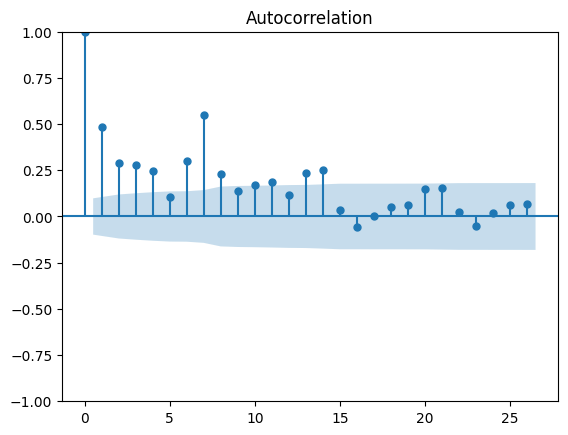

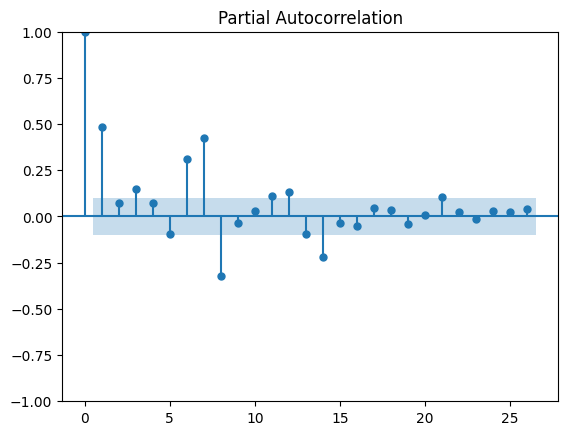

In [149]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(train)
plot_pacf(train)
plt.show()

In [150]:
from pmdarima import auto_arima

arima_model = auto_arima(
    train,
    seasonal=False,   # ARIMA
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=1,               # because ADF stationary tha after differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5474.405, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5435.888, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5367.471, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5472.405, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5347.711, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5347.694, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=5400.277, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=5349.624, Time=0.22 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=5349.623, Time=0.34 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=5347.749, Time=0.19 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=5388.927, Time=0.05 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=5351.585, Time=0.30 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=5345.803, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=5345.830, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0]          

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Create ARIMA model
model_arima = ARIMA(
    train,
    order=(0,1,2)
)

# Fit ARIMA model
model_fit_arima = model_arima.fit()

print(model_fit_arima.summary())

In [153]:
forecast_arima = model_fit_arima.forecast(
    steps=len(test)
)

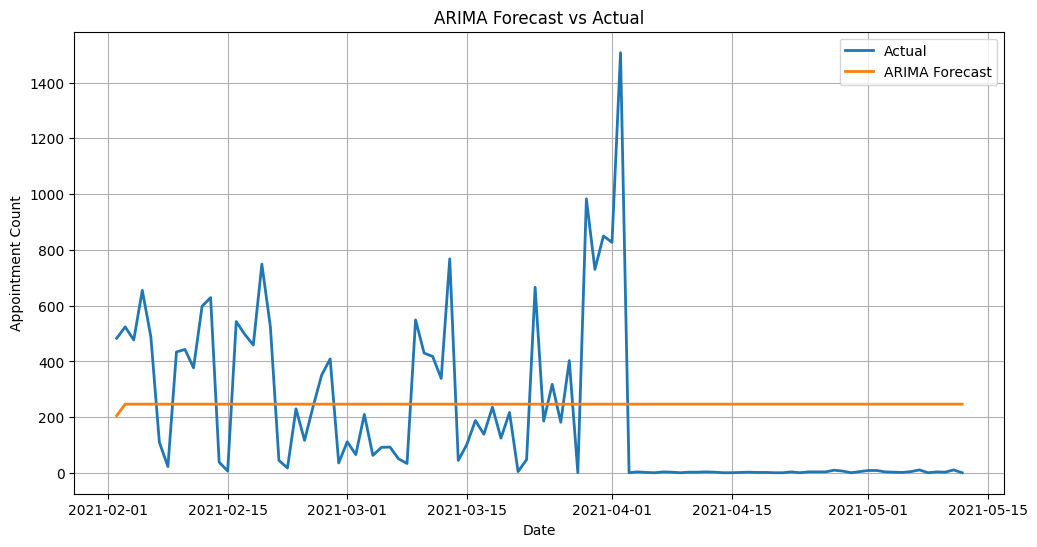

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Actual values
plt.plot(
    test.index,
    test,
    label="Actual",
    linewidth=2
)

# ARIMA Forecast
plt.plot(
    test.index,
    forecast_arima,
    label="ARIMA Forecast",
    linewidth=2
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Appointment Count")
plt.legend()
plt.grid(True)

plt.show()

In [163]:
result_df = pd.DataFrame({
    "Actual": test.values,
    "Predicted": forecast_arima.values
})

print(result_df.head())

   Actual   Predicted
0     483  205.383940
1     524  246.860983
2     477  246.860983
3     655  246.860983
4     489  246.860983


1.Actual (blue):
bahut spiky + high variance
value may 0, sometime 1500 jump

2.Forecast (orange):
almost flat line (~250)
this model is not capture the variation.

3.Model become underfitting (because average vale is ~250 so that model predict )

4.ARIMA(0,1,2) weak structure
Data me strong patterns:
weekly seasonality ✔
sudden spikes ✔
high variance ✔

Differencing (d=1)

data beacome over-smooth 

ARIMA fail for this dataset (forecast-wise)


Model Fit but prediction power is Week

In [ ]:
# Model Training: SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Create SARIMA model
model_sarima = SARIMAX(
    train,
    order=(1,1,2),
    seasonal_order=(1,1,1,7)
)

# Fit model
model_fit_sarima = model_sarima.fit()

# Summary
print(model_fit_sarima.summary())

In [158]:
forecast_sarima = model_fit_sarima.forecast(
    steps=len(test)
)

In [165]:
import numpy as np

train_log = np.log1p(train)
test_log = np.log1p(test)

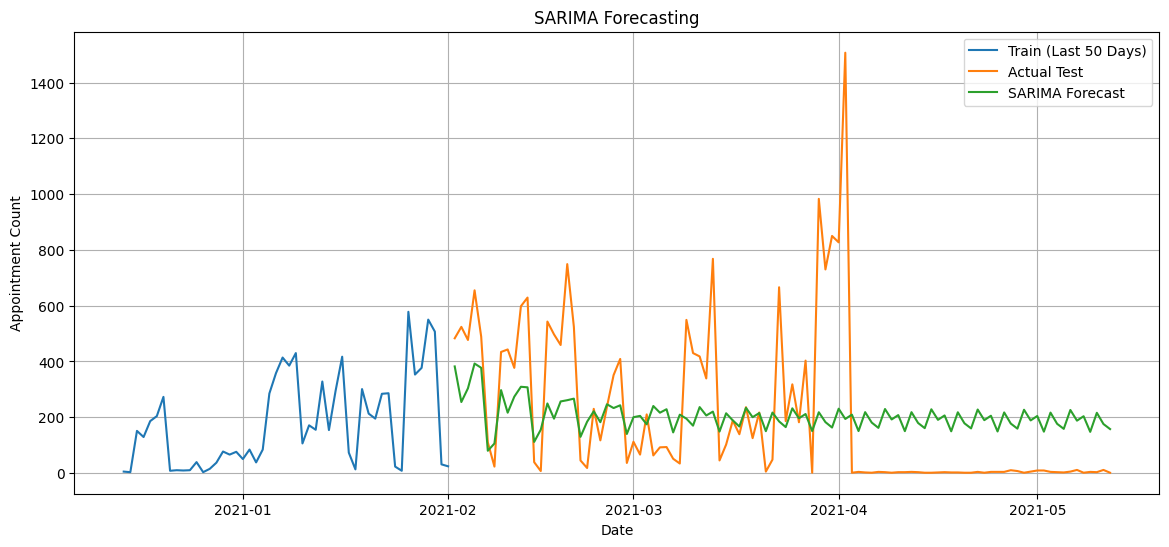

In [166]:
# Forecast
forecast_sarima = model_fit_sarima.forecast(
    steps=len(test)
)

plt.figure(figsize=(14,6))

# Last 50 train points
plt.plot(
    train.index[-50:],
    train[-50:],
    label="Train (Last 50 Days)"
)

# Actual test
plt.plot(
    test.index,
    test,
    label="Actual Test"
)

# Forecast
plt.plot(
    test.index,
    forecast_sarima,
    label="SARIMA Forecast"
)

plt.title("SARIMA Forecasting")
plt.xlabel("Date")
plt.ylabel("Appointment Count")
plt.legend()
plt.grid(True)

plt.show()

Compare Actual vs Predicted

In [168]:
result_df = pd.DataFrame({
    "Actual": test.values,
    "Predicted": forecast_sarima.values
})

print(result_df.head())

   Actual   Predicted
0     483  382.140570
1     524  254.510835
2     477  303.739145
3     655  392.430258
4     489  377.196175


In [169]:
from pmdarima import auto_arima

sarima_model = auto_arima(
    train,

    # Seasonal model ON
    seasonal=True,
    m=7,   # weekly seasonality

    # ARIMA part (p,d,q)
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,

    # Seasonal part (P,D,Q)
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,

    d=1,
    D=1,

    trace=True,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",

    information_criterion="aic"
)

print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=5327.872, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=5260.926, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=5237.893, Time=0.12 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=5262.767, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=inf, Time=0.25 sec
 ARIMA(0,1,1)(0,1,2)[7]             : AIC=5195.519, Time=0.47 sec
 ARIMA(0,1,1)(1,1,2)[7]             : AIC=inf, Time=0.46 sec
 ARIMA(0,1,0)(0,1,2)[7]             : AIC=5257.791, Time=0.23 sec
 ARIMA(1,1,1)(0,1,2)[7]             : AIC=inf, Time=0.54 sec
 ARIMA(0,1,2)(0,1,2)[7]             : AIC=inf, Time=0.41 sec
 ARIMA(1,1,0)(0,1,2)[7]             : AIC=5206.684, Time=0.27 sec
 ARIMA(1,1,2)(0,1,2)[7]             : AIC=inf, Time=0.67 sec
 ARIMA(0,1,1)(0,1,2)[7] intercept   : AIC=5197.515, Time=0.39 sec

Best model:  ARIMA(0,1,1)(0,1,2)[7]          
Total fit time: 3.911 seconds
                                       SARIMAX 

In [170]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# ========= ARIMA Evaluation ========= #

# Metrics
mae_arima = mean_absolute_error(
    test,
    forecast_arima
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test,
        forecast_arima
    )
)

# Avoid divide by zero problem
mape_arima = np.mean(
    np.abs(
        (test - forecast_arima)
        /
        (test + 1e-10)
    )
) * 100

r2_arima = r2_score(
    test,
    forecast_arima
)

# Report
print("=" * 40)
print("      ARIMA MODEL REPORT")
print("=" * 40)

print(f"MAE   : {mae_arima:.2f}")
print(f"RMSE  : {rmse_arima:.2f}")
print(f"MAPE  : {mape_arima:.2f}%")
print(f"R²    : {r2_arima:.3f}")

print("=" * 40)

      ARIMA MODEL REPORT
MAE   : 241.42
RMSE  : 286.77
MAPE  : 5100.80%
R²    : -0.023


In [171]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# ========= SARIMA Evaluation ========= #

# Metrics
mae_sarima = mean_absolute_error(
    test,
    forecast_sarima
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test,
        forecast_sarima
    )
)

# Safe MAPE (avoid divide-by-zero issue)
mape_sarima = np.mean(
    np.abs(
        (test - forecast_sarima)
        /
        (test + 1e-10)
    )
) * 100

r2_sarima = r2_score(
    test,
    forecast_sarima
)

# Report
print("=" * 40)
print("      SARIMA MODEL REPORT")
print("=" * 40)

print(f"MAE   : {mae_sarima:.2f}")
print(f"RMSE  : {rmse_sarima:.2f}")
print(f"MAPE  : {mape_sarima:.2f}%")
print(f"R²    : {r2_sarima:.3f}")

print("=" * 40)

      SARIMA MODEL REPORT
MAE   : 199.31
RMSE  : 264.64
MAPE  : 3846.87%
R²    : 0.129


| Metric |    ARIMA |       SARIMA | Better   |
| ------ | -------: | -----------: | -------- |
| MAE    |   241.42 |   **199.31** | ✅ SARIMA |
| RMSE   |   286.77 |   **264.64** | ✅ SARIMA |
| MAPE   | 5100.80% | **3846.87%** | ✅ SARIMA |
| R²     |   -0.023 |    **0.129** | ✅ SARIMA |


ARIMA

Flat predictions
Negative R²
Weak

SARIMA

Better than ARIMA
Weekly seasonality capture but
Still weak

In [172]:
import pickle
import os

# Save trained ARIMA model
with open(
    "../models/forcasting_Regration/arima_model.pkl",
    "wb"
) as f:
    pickle.dump(model_fit_arima, f)

print("ARIMA model saved successfully!")

ARIMA model saved successfully!


In [173]:
import pickle

with open(
    "../models/forcasting_Regration/sarima_model.pkl",
    "wb"
) as f:
    pickle.dump(model_fit_sarima, f)

print("SARIMA model saved successfully!")

SARIMA model saved successfully!
